In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv('diabetes.csv')


print("First 5 rows of dataset:")
print(df.head())


print("\nDataset Info:")
print(df.info())


print("\nStatistical Summary:")
print(df.describe())

First 5 rows of dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    in


Missing values in dataset:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


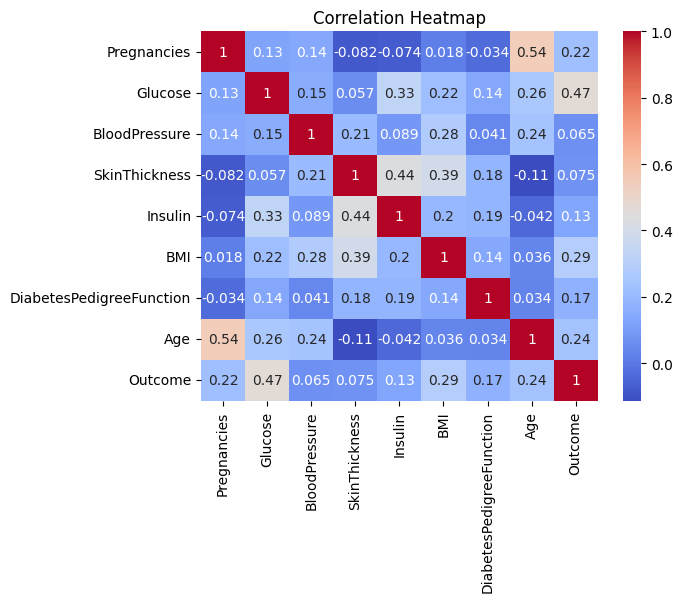

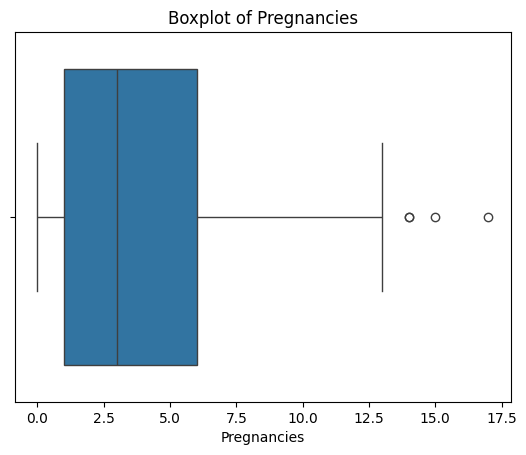

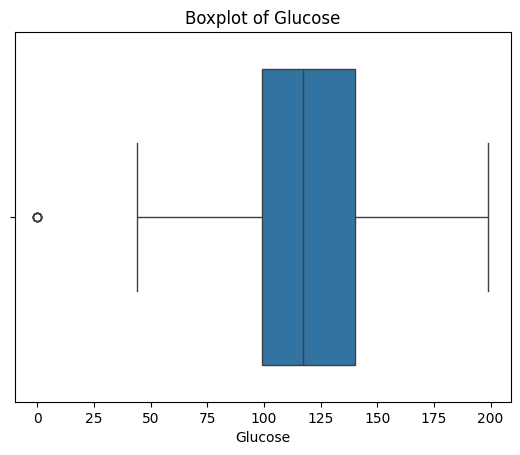

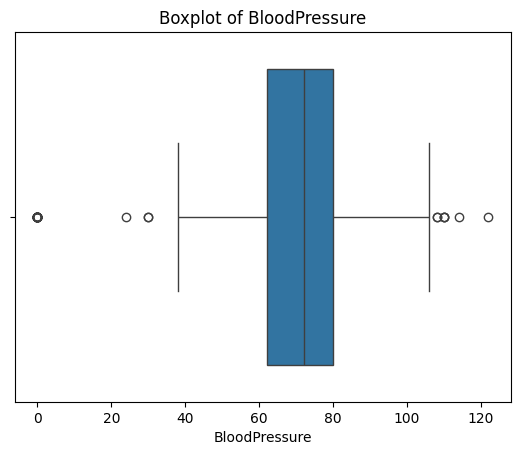

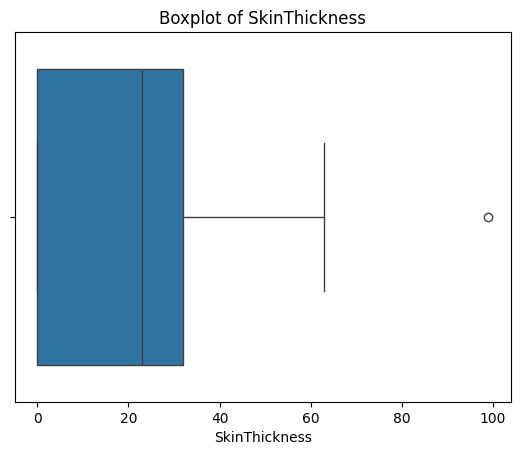

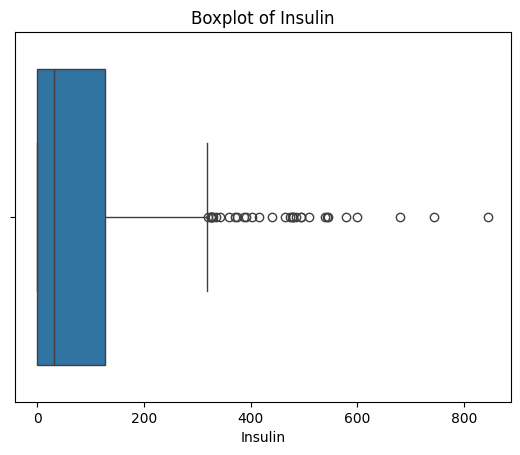

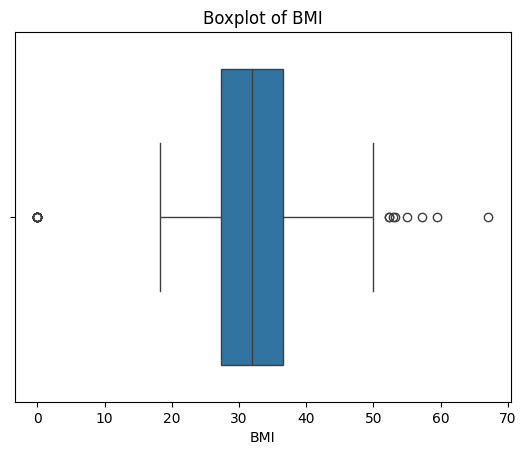

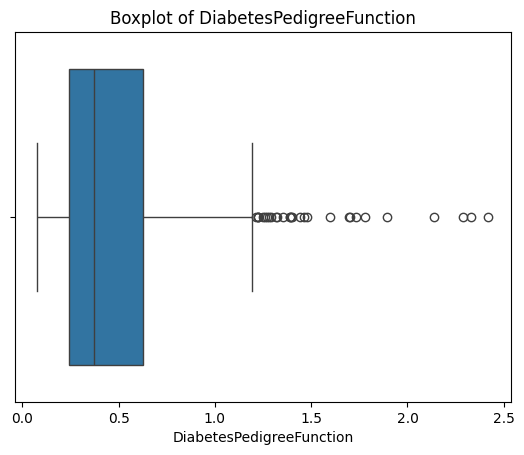

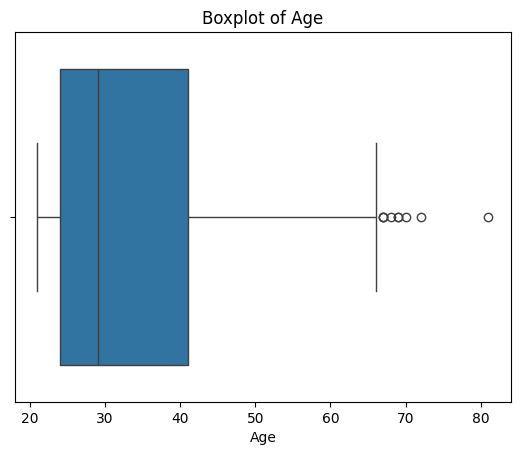

In [3]:
print("\nMissing values in dataset:")
print(df.isnull().sum())


# Correlation heatmap
plt.figure()
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# Boxplot for outlier analysis
for col in df.columns[:-1]:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [4]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [5]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']


for col in cols_with_zero:
    X[col] = X[col].replace(0, X[col].mean())

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train_scaled, y_train)


y_pred_knn = knn.predict(X_test_scaled)


print("\nKNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nKNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nKNN Classification Report:\n", classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.7922077922077922

KNN Confusion Matrix:
 [[39 11]
 [ 5 22]]

KNN Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.78      0.83        50
           1       0.67      0.81      0.73        27

    accuracy                           0.79        77
   macro avg       0.78      0.80      0.78        77
weighted avg       0.81      0.79      0.80        77



In [9]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)


y_pred_nb = nb.predict(X_test_scaled)


print("\nNaive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nNaive Bayes Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nNaive Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))


Naive Bayes Accuracy: 0.7142857142857143

Naive Bayes Confusion Matrix:
 [[36 14]
 [ 8 19]]

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.72      0.77        50
           1       0.58      0.70      0.63        27

    accuracy                           0.71        77
   macro avg       0.70      0.71      0.70        77
weighted avg       0.73      0.71      0.72        77

